### iLQR template code

Author: Max Muchen Sun

Date: May 5, 2025

*An example of using "solve_bvp" is included in "ME314OptimalControlNotes.pdf* on Canvas.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
import ergodic_metric as eg

In [7]:
### define parameters

dt = 0.1
x0 = np.array([0.3, 0.3, 0, 0])
tsteps = 100
init_u_traj = np.tile(np.array([0.0, 0.0]), reps=(tsteps,1))

Q_x = np.diag([.001, .001])
R_u = np.diag([.001, .001])
P1 = np.diag([0, 0, 0, 0])

Q_z = np.diag([.001, .001, .001, .001])
R_v = np.diag([.001, .001])
q = 1

In [8]:
def dyn(xt, ut):
    return np.array([xt[2], xt[3], ut[0], ut[1]])


def get_A(t, st, ut):
    A = np.zeros((4, 4))
    A[0, 2] = 1.0   # d(x1dot)/d(v1)
    A[1, 3] = 1.0   # d(x2dot)/d(v2)
    return A


def get_B(t, st, ut):
    B = np.zeros((4, 2))
    B[2, 0] = 1.0   # d(v1dot)/d(u1)
    B[3, 1] = 1.0   # d(v2dot)/d(u2)
    return B


def step(xt, ut):
    return integrate(lambda x: dyn(x, ut), xt, dt)


def integrate(f, xt, dt):
    """
    This function takes in an initial condition x(t) and a timestep dt,
    as well as a dynamical system f(x) that outputs a vector of the
    same dimension as x(t). It outputs a vector x(t+dt) at the future
    time step.

    Parameters
    ============
    f: Python function
        derivate of the system at a given step x(t),
        it can considered as dot{x}(t) = func(x(t))
    xt: NumPy array
        current step x(t)
    dt:
        step size for integration

    Return
    ============
    new_xt:
        value of x(t+dt) integrated from x(t)
    """
    k1 = dt * f(xt)
    k2 = dt * f(xt+k1/2.)
    k3 = dt * f(xt+k2/2.)
    k4 = dt * f(xt+k3)
    new_xt = xt + (1/6.) * (k1+2.0*k2+2.0*k3+k4)
    return new_xt

def traj_sim(x0, ulist):
    tsteps = ulist.shape[0]
    x_traj = np.zeros((tsteps, 4))
    xt = x0.copy()
    for t in range(tsteps):
        xt_new = step(xt, ulist[t])
        x_traj[t] = xt_new.copy()
        xt = xt_new.copy()
    return x_traj


def loss(t, xt, ut):
    u_loss = 1/2 * ut @ R_u @ ut

    return u_loss

#precompute hk for normalization of the basis functions
hk = np.zeros(eg.ks.shape[0])
for i, k_vec in enumerate(eg.ks):
    hk[i] = np.sqrt(np.sum(np.square(np.prod(np.cos(np.pi * k_vec / eg.L_list * eg.grids), axis=1))) * eg.dx * eg.dy)

def traj_ck(x_traj):
    traj_coefficients = np.zeros(eg.ks.shape[0])
    for i, k_vec in enumerate(eg.ks):
        # step 1: evaluate the basis function over the trajectory
        fk_vals = np.prod(np.cos(np.pi * k_vec / eg.L_list * x_traj), axis=1)
        fk_vals /= hk[i]

        # step 2: approximate the integral through the Riemann sum for the coefficient
        ck = np.sum(fk_vals) * 1 / (x_traj.shape[0]) #equivalent to tsteps here
        traj_coefficients[i] = ck
    return traj_coefficients

def grad_fk(x):
    output = np.zeros((eg.ks.shape[0], 2))
    for i, k_vec in enumerate(eg.ks):
        costerm1 = np.cos(k_vec[0] * np.pi * x[0] / eg.L_list[0])
        costerm2 = np.cos(k_vec[1] * np.pi * x[1] / eg.L_list[1])
        sinterm1 = np.sin(k_vec[0] * np.pi * x[0] / eg.L_list[0])
        sinterm2 = np.sin(k_vec[1] * np.pi * x[1] / eg.L_list[1])
        grad_x1 = -k_vec[0] * np.pi / eg.L_list[0] * sinterm1 * costerm2
        grad_x2 = -k_vec[1] * np.pi / eg.L_list[1] * costerm1 * sinterm2
        output[i] = np.array([grad_x1, grad_x2]) / hk[i]
    return output

b_eps = 0.01      # margin inside each wall
b_w   = 100.0     # penalty weight (tune alongside q)

def barrier(x):
    """Scalar penalty at a single state x (2-vector)."""
    x = np.asarray(x, dtype=float)
    lo = np.maximum(0.0, b_eps - x)                 # how far past the low wall
    hi = np.maximum(0.0, x - (eg.L_list - b_eps))   # how far past the high wall
    return np.sum(lo**2 + hi**2)

def dbarrier(x):
    """Gradient of barrier wrt x (2-vector)."""
    x = np.asarray(x, dtype=float)
    lo = np.maximum(0.0, b_eps - x)
    hi = np.maximum(0.0, x - (eg.L_list - b_eps))
    return 2.0*hi - 2.0*lo

def dldu(t, xt, ut):
    dvec = R_u @ ut
    return dvec

In [9]:
T = tsteps * dt
def ilqr_iter(x0, u_traj):
    """
    :param x0: initial state of the system
    :param u_traj: current estimation of the optimal control trajectory
    :return: the descent direction for the control
    """
    # forward simulate the state trajectory
    x_traj = traj_sim(x0, u_traj)
    ck_list = traj_ck(x_traj[:,:2])

    w = (2 * q / T) * eg.lamk_list * (ck_list - eg.coefficients)

    # compute other variables needed for specifying the dynamics of z(t) and p(t)
    A_list = np.zeros((tsteps, 4, 4))
    B_list = np.zeros((tsteps, 4, 2))
    a_list = np.zeros((tsteps, 4))
    b_list = np.zeros((tsteps, 2))
    for t_idx in range(tsteps):
        t = t_idx * dt
        A_list[t_idx] = get_A(t, x_traj[t_idx], u_traj[t_idx])
        B_list[t_idx] = get_B(t, x_traj[t_idx], u_traj[t_idx])
        G = grad_fk(x_traj[t_idx,:2])
        a_list[t_idx] = np.concatenate([G.T @ w + b_w * dbarrier(x_traj[t_idx, :2]), [0, 0]])
        b_list[t_idx] = dldu(t, x_traj[t_idx], u_traj[t_idx])

    p1 = np.zeros(4)

    def zp_dyn(t, zp):
        t_idx = (t/dt).astype(int)
        At = A_list[t_idx]
        Bt = B_list[t_idx]
        at = a_list[t_idx]
        bt = b_list[t_idx]

        M_11 = At
        M_12 = -Bt @ np.linalg.inv(R_v) @ Bt.T
        M_21 = -Q_z
        M_22 = - At.T
        dyn_mat = np.block([
            [M_11, M_12],
            [M_21, M_22]
        ])

        m_1 = - Bt @ np.linalg.inv(R_v) @ bt
        m_2 = -at
        dyn_vec = np.hstack([m_1, m_2])

        return dyn_mat @ zp + dyn_vec

    # this will be the actual dynamics function you provide to solve_bvp,
    # it takes in a list of time steps and corresponding [z(t), p(t)]
    # and returns a list of [zdot(t), pdot(t)]
    def zp_dyn_list(t_list, zp_list):
        list_len = len(t_list)
        zp_dot_list = np.zeros((8, list_len))
        for _i in range(list_len):
            zp_dot_list[:,_i] = zp_dyn(t_list[_i], zp_list[:,_i])
        return zp_dot_list

    # boundary condition (inputs are [z(0),p(0)] and [z(T),p(T)])
    def zp_bc(zp_0, zp_T):
        return np.hstack([zp_0[:4], zp_T[4:] - p1])

    ### The solver will say it does not converge, but the returned result
    ### is numerically accurate enough for our use
    tlist = np.arange(tsteps) * dt
    res = solve_bvp(
        zp_dyn_list, zp_bc, tlist, np.zeros((8,tsteps)),
        max_nodes=100
    )
    zp_traj = res.sol(tlist).T

    z_traj = zp_traj[:,:4]
    p_traj = zp_traj[:,4:]

    v_traj = np.zeros((tsteps, 2))
    for _i in range(tsteps):
        At = A_list[_i]
        Bt = B_list[_i]
        at = a_list[_i]
        bt = b_list[_i]

        zt = z_traj[_i]
        pt = p_traj[_i]

        vt = - np.linalg.inv(R_v) @ (Bt.T @ pt + bt)
        v_traj[_i] = vt

    # directional derivative of J at u_traj in the direction v_traj:
    # DJ(u) . v = integral of [ a(t)^T z(t) + b(t)^T v(t) ] dt
    # (z_traj is the linearized state response to v_traj, from the BVP)
    dJ_dv = 0.0
    for _i in range(tsteps):
        dJ_dv += (a_list[_i] @ z_traj[_i] + b_list[_i] @ v_traj[_i]) * dt

    return v_traj, dJ_dv

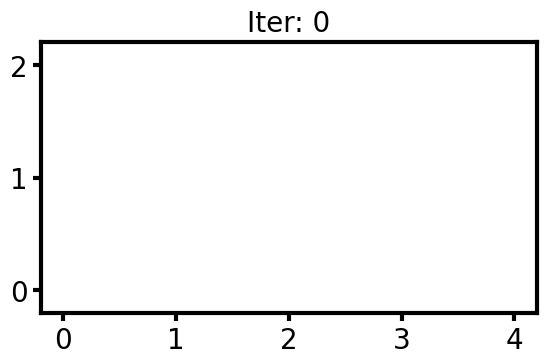

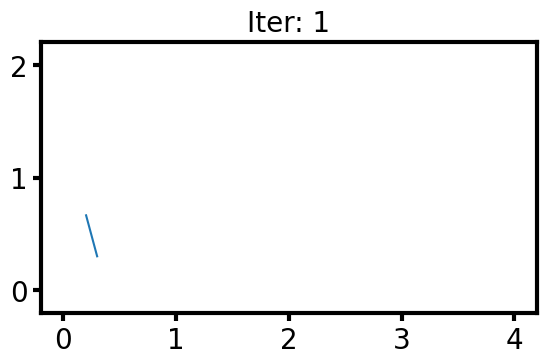

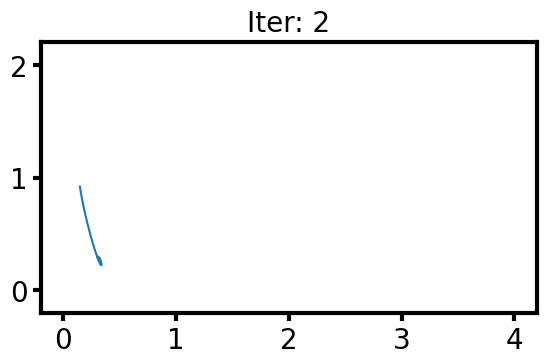

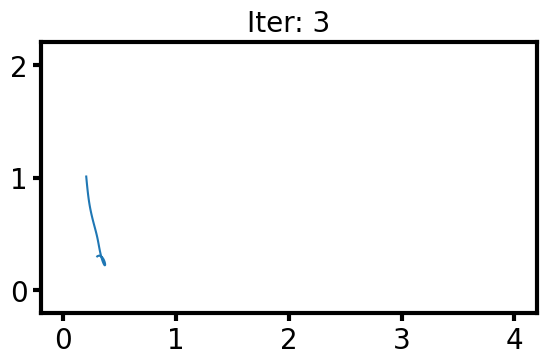

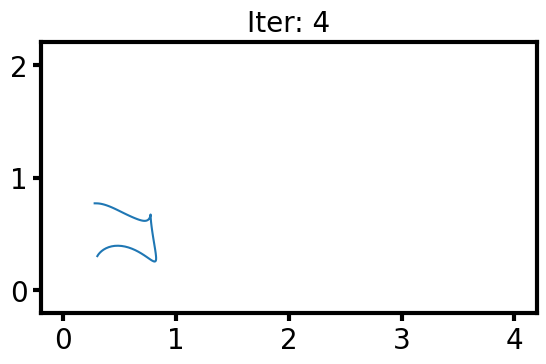

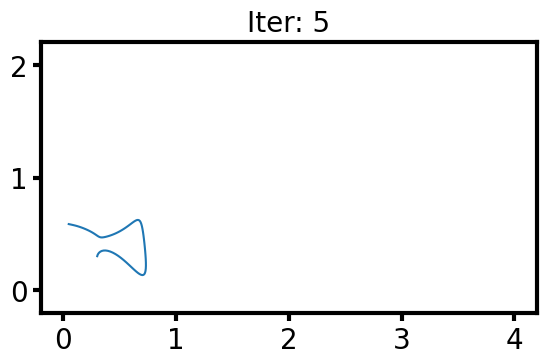

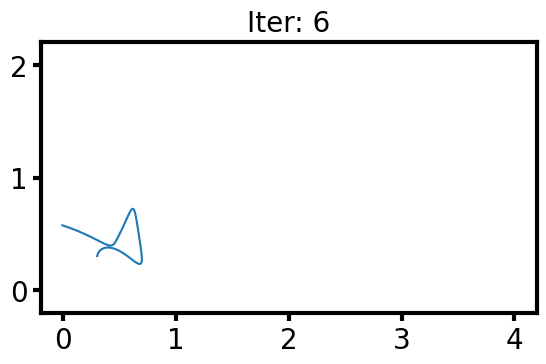

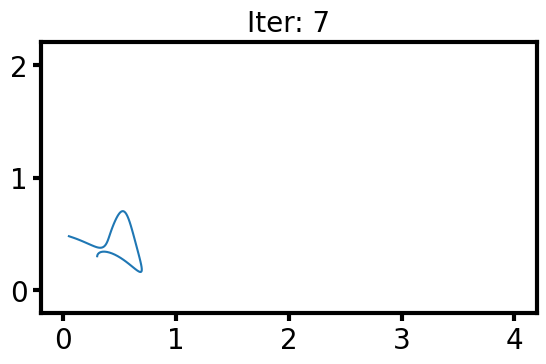

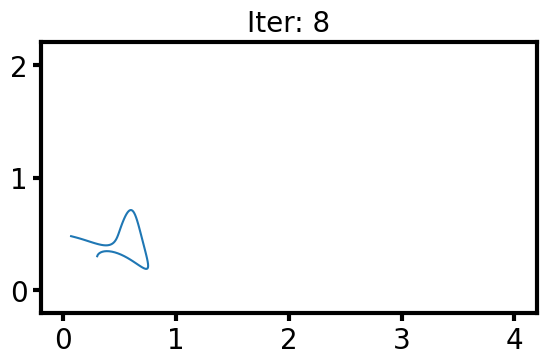

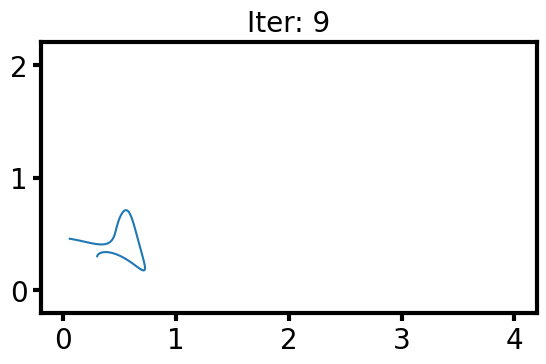

In [10]:
# Start iLQR iterations here
def total_cost(u_traj):
    """True nonlinear objective J(u): running cost integral + terminal cost.
    Requires a full forward simulation for every evaluation."""
    x_traj = traj_sim(x0, u_traj)
    J = 0.0
    J += q * np.sum(eg.lamk_list * np.square(traj_ck(x_traj[:,:2]) - eg.coefficients))
    for t_idx in range(tsteps):
        J += loss(t_idx * dt, x_traj[t_idx], u_traj[t_idx]) * dt
        J += b_w * barrier(x_traj[t_idx,:2]) * dt 
    return J

u_traj = init_u_traj.copy()
init_x_traj = traj_sim(x0, init_u_traj)  # saved for the summary plot
J_list = []
for iter in range(10):
    # forward simulate the current trajectory
    x_traj = traj_sim(x0, u_traj)

    # visualize the current trajectory
    fig, ax = plt.subplots(1, 1)
    ax.set_title('Iter: {:d}'.format(iter))
    ax.set_aspect('equal')
    ax.set_xlim(-0.2, 4.2)
    ax.set_ylim(-0.2, 2.2)
    ax.plot(x_traj[:,0], x_traj[:,1], linestyle='-', color='C0')
    plt.show()
    plt.close()

    # get descent direction
    v_traj, dJ_dv = ilqr_iter(x0, u_traj)

    # Armijo line search parameters
    gamma = 1.0  # initial step size
    alpha = 1e-04
    beta = 0.5

    ### Implement Armijo line search here to update step size gamma
    J_curr = total_cost(u_traj)
    J_list.append(J_curr)
    if dJ_dv >= 0:
        print('Warning: dJ_dv = {:.3e} is not a descent direction'.format(dJ_dv))
    while total_cost(u_traj + gamma * v_traj) > J_curr + alpha * gamma * dJ_dv:
        gamma *= beta
        if gamma < 1e-08:  # safety floor so a bad direction can't loop forever
            break
    # update control for the next iteration
    u_traj += gamma * v_traj

J_list.append(total_cost(u_traj))

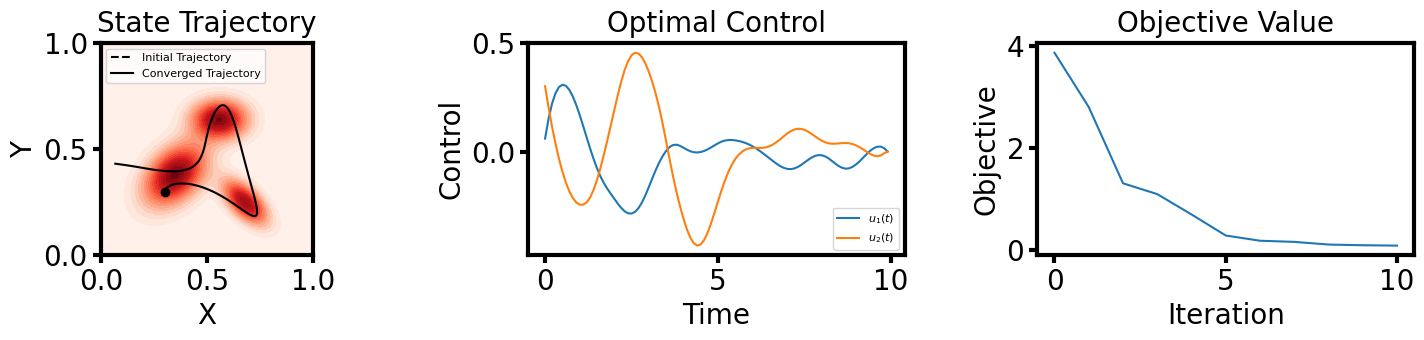

In [11]:
x_traj_conv = traj_sim(x0, u_traj)

# prepend the initial condition so trajectories start at x0
init_xy = np.vstack([x0[:2], init_x_traj[:, :2]])
conv_xy = np.vstack([x0[:2], x_traj_conv[:, :2]])

tlist = np.arange(tsteps) * dt

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

# --- State trajectory over the target distribution ---
ax = axes[0]
ax.set_title('State Trajectory')
# GMM contour underneath
pdf_grid = eg.pdf(eg.grids).reshape(eg.grids_x.shape)
ax.contourf(eg.grids_x, eg.grids_y, pdf_grid, levels=20, cmap='Reds')
# trajectories on top
ax.plot(init_xy[:, 0], init_xy[:, 1], linestyle='--', color='k',
        label='Initial Trajectory')
ax.plot(conv_xy[:, 0], conv_xy[:, 1], linestyle='-', color='k',
        label='Converged Trajectory')
ax.plot(x0[0], x0[1], marker='o', color='k', markersize=6)  # start point
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')
ax.set_xlim(0.0, eg.L_list[0])
ax.set_ylim(0.0, eg.L_list[1])
ax.legend(loc='upper left', fontsize=8)

# --- Optimal control ---
ax = axes[1]
ax.set_title('Optimal Control')
ax.plot(tlist, u_traj[:, 0], color='C0', label=r'$u_1(t)$')
ax.plot(tlist, u_traj[:, 1], color='C1', label=r'$u_2(t)$')
ax.set_xlabel('Time')
ax.set_ylabel('Control')
ax.legend(loc='lower right', fontsize=8)

# --- Objective value ---
ax = axes[2]
ax.set_title('Objective Value')
ax.plot(np.arange(len(J_list)), J_list, color='C0')
ax.set_xlabel('Iteration')
ax.set_ylabel('Objective')

plt.tight_layout()
plt.savefig('ilqr_summary.png', dpi=150)
plt.show()